<p>
<h1><b><center>Mecánica de Medios Continuos</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Tarea 6</center></b><h2>
<h3><b><center>Soluciones a las ecuaciones de Navier-Stokes</center></b><h3>

## Enunciado

**Objetivo**: Ilustrar los campos de velocidad, presión y estrés de algunas soluciones analíticas bien conocidas de las ecuaciones de Navier-Stokes.

**Procedimiento**:

Para cada uno de los problemas a continuación, encontrar los campos mencionados y dibujar diagramas de: campo vectorial de velocidades, líneas de corriente, campo de presiones y campo de esfuerzos usando como referencia el notebook que usamos en clase para representar esos mismos campos en el caso de la solución para el flujo de Stokes alrededor de una esfera y el cálculo correspondiente que hicimos de la fuerza de arrastre.

1. **Flujo alrededor de cilindro**. Resolver las ecuaciones de Navier-Stokes en el caso de los problemas de *cilindro en un corriente cruzada* (página 222, Lautrup, 2011) y el *efecto Magnus* (página 224). Hacer, en ambos casos, diagramas del campo de velocidades y de presión.

2. **Flujo laminar cilíndrico**. Resolver las ecuaciones de Navier-Stokes en el caso de el problema de *flujo laminar cilíndrico* (página 277, Lautrup, 2011). Hacer diagrama del campo de velocidades, campo de presión, estrés. Hacer una animación del movimiento de partículas (particle trajectories) en este caso.

3. **Flujo inducido por gravedad**. Resolver las ecuaciones de Navier-Stokes en el caso de los problemas de *flujo entre placas paralelas inclinadas* y *flujo inclinado con una superficie libre* (página 266, Lautrup, 2011). Hacer diagramas del campo de velocidades y de presión en cada caso.

4. **Flujo en tubería**. Resolver las ecuaciones de Navier-Stokes en el caso de el problema de *flujo laminar en tubería* (página 268, Lautrup, 2011). Hacer diagrama del campo de velocidades y calcular numéricamente el valor de cantidades como Q y U.



**Resultados esperados**:

- Este notebook con el procedimiento debidamente comentado.

- Gráficos esperados:
  - Gráficos de campos vectoriales de velocidades (cuando aplique).
  - Gráficos de líneas de corriente (cuando aplique).
  - Gráficos de contornos del campo de presión (cuando aplique).
  - Gráficos de presión, estrés, velocidad como función de coordenadas (cuando aplique).

- En caso de utilizar ayudas como `ChatGPT` o códigos de `Stack Over Flow` debe citar debidamente la fuente, pero también entender a cabalidad el código, el profesor puede pedir justificación.

## Solución

In [18]:
!pip install celluloid &> /dev/null

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from matplotlib.patches import Circle, FancyArrowPatch

from celluloid import Camera
from IPython.core.display import HTML

### 1) Flujo alrededor de cilindro

Un cilindro circular con eje a lo largo del eje $z$ y radio $a$ se encuentra sumergido en un "viento transversal" asintóticamente uniforme con velocidad $U$ a lo largo del eje $x$.

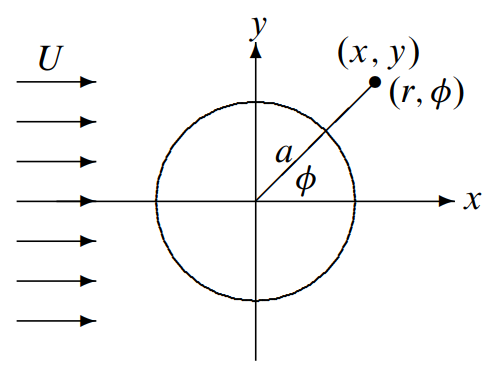

En el eje $z$ existe invarianza traslacional, por tanto el potencial de velocidad $\Psi(x,y)$ y la función de flujo $ψ(x,y)$ son ambos independientes de $z$.

Las componentes del campo de velocidades en coordenadas cilíndricas está dado por:

$$\begin{aligned}
  & v_r = \nabla_r \Psi = \frac{\partial \Psi}{\partial r} = U \cos \phi\left(1-\frac{a^2}{r^2}\right)
  \\
  & v_\phi = \nabla_\phi \Psi = \frac{1}{r} \frac{\partial \Psi}{\partial \phi} = -U \sin \phi\left(1+\frac{a^2}{r^2}\right)  \quad (1)
  \\
  & v_z = 0
\end{aligned}$$

\
**La presión**, en ausencia de la gravedad y normalizada para desaparecer en el infinito ($r \to \infty$), está dada por la ecuación:

$$ P = \frac{1}{2} \rho_0 U^2 \frac{a^2}{r^2}\left(4 \cos ^2 \phi-2-\frac{a^2}{r^2}\right) \quad (2)$$

In [20]:
def vfield(x,y,z, t,vpars):
  U,a = vpars

  # r = (x**2 + y**2 + z**2)**0.5
  r = (x**2 + y**2)**0.5
  phi = np.arctan2(y,x)

  # Coordenadas cilíndricas de la velocidad
  vr = U*np.cos(phi)*(1 - (a/r)**2)
  vphi = -U*np.sin(phi)*(1 + (a/r)**2)

  # Vectores unitarios cilíndricos
  er = np.array([np.cos(phi), np.sin(phi), 0])
  ephi = np.array([-np.sin(phi), np.cos(phi), 0])

  # Campo de velocidades en coords. cartesianas
  v = vr*er + vphi*ephi

  return v
# ==============================================================================

# Líneas de corriente
def streamline(Y, t,t0, vfield,vpars):
  x,y,z = Y

  vx,vy,vz = vfield(x,y,z, t0,vpars)

  dxdt = vx
  dydt = vy
  dzdt = vz

  return [dxdt,dydt,dzdt]

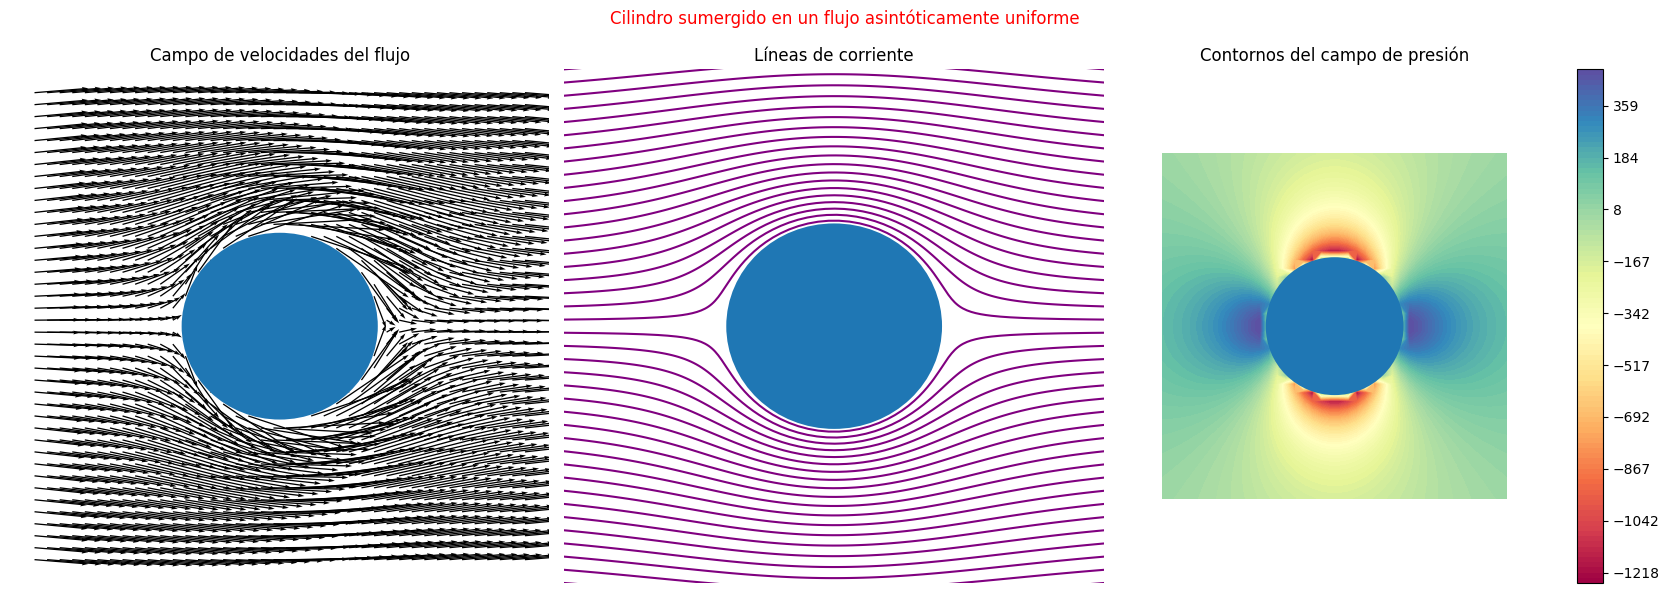

In [21]:
vpars = U, a = 1, 0.3   # Velocidad de escala, radio
rho0 = 1000    # [kg/m^3] - Densidad del flujo
t0 = 1      # Instante inicial

NG = 40     # Tamaño de la malla
xs = np.linspace(-2.5*a, 2.5*a, NG)
ys = np.linspace(-2.5*a, 2.5*a, NG)
zs = np.zeros(NG)

XS,YS = np.meshgrid(xs,ys)
ZS = np.zeros_like(XS)

t = 0
VXS = np.zeros_like(XS)
VYS = np.zeros_like(XS)
VZS = np.zeros_like(XS)

for i in range(NG):
  for j in range(NG):
    if np.sqrt(XS[i,j]**2 + YS[i,j]**2) >= a:
      VXS[i,j], VYS[i,j], VZS[i,j] = vfield(XS[i,j],YS[i,j],ZS[i,j], t,vpars)

fig = plt.figure(figsize=(17,6))
fig.suptitle('Cilindro sumergido en un flujo asintóticamente uniforme', color='r')

# ======================== Campo de velocidad ========================
#
plt.subplot(131)
plt.title('Campo de velocidades del flujo')
plt.quiver(XS,YS, VXS,VYS, scale=10)
plt.gca().add_patch(Circle((0,0),a,fill='blue'))
plt.axis("off")

# ======================== Líneas de corriente ========================
#
plt.subplot(132)
plt.title('Líneas de corriente')

ts = np.linspace(0,30,2000)
x = XS[0,0]

# Integramos las velocidades que adquieran partículas iniciando desde la izquierda
for y in YS[:,0]:
  # Por la invariabilidad en z, sólo integramos en xy
  Y0 = [x,y,0]
  sols = odeint(streamline,Y0,ts, args=(t0,vfield,vpars))
  vxt, vyt = sols[:,0], sols[:,1]
  plt.plot(vxt, vyt, c='purple')

plt.gca().add_patch(Circle((0,0),a, fill='blue'))
plt.xlim(-2.5*a, 2.5*a)
plt.ylim(-2.5*a, 2.5*a)
plt.axis("off")

# ======================== Campo de presión ========================
#
RS = (XS**2 + YS**2)**0.5
PHIS = np.arctan2(YS,XS)

PS = 0.5*rho0*U**2*(a/RS)**2*(4*np.cos(PHIS)**2 - 2 - (a/RS)**2)
PS[RS < a] = 0    # Condición de frontera

plt.subplot(133)
plt.title('Contornos del campo de presión')
c = plt.contourf(XS,YS, PS, levels=np.linspace(PS.min(),PS.max(),100), cmap="Spectral")
plt.colorbar(c)
plt.gca().add_patch(Circle((0,0), a, fill='blue',zorder=100))
plt.axis("equal")
plt.axis("off")

fig.tight_layout()

**Observaciones:**

* Notamos del campo de presión que en los extremos superior e inferior la presión del flujo es menor a la presión que existe en los extremos laterales izquierdo y derecho que es por donde se dirije el flujo. En los laterales "verticales" el gradiente de presión actúa hacia afuera del cilindro, mientras que en los laterales "horizontales" actúa hacia el cilindro.

  Sin embargo, también hemos de notar que exactamente en la superficie

  Esto se ve reflejado en el campo de velocidades con el hecho de que la velocidad que alcanza el fluido en los laterales superior e inferior es mayor (menor presión), caso contrario de lo que sucede en los laterales izquierdo y derecho (máxima presión) donde el fluido choque con el cilindro a la izquierda y contra capas de sí mismo a la derecha.

* En el campo de velocidad podemos notar con más detalle esto. En la región izquierda, donde las capas chocan con el cilindro las velocidades disminuyen su velocidad gracias al efecto de cizalladura entre capas que proviene desde la fricción con el cilindro, pero esta crece a medida que las capas alcanzan los extremos superior e inferior y crean una región en la que las velocidades alcanzan una mayor amplitud alejadas de la superficie y por tanto regiones de baja presión.

* Sin embargo, este no es el caso del fluido muy cerca a la superficie. Algunas partículas que chocan con el cilindro en el lateral izquierdo recorren toda la superficie y chocan en lateral derecho, y es precisamente en estos laterales que se crean las regiones de alta presión.

#### Efecto Magnus

El efecto Magnus es un fenómeno físico en el que un objeto en rotación experimenta una fuerza lateral debido a la interacción entre su movimiento de rotación y el flujo circundante. Es una consecuencia de la ley de Bernoulli, la diferencia de presión del fluido en los lados opuestos del objeto que gira genera sustentación y desvía la trayectoria del objeto.

\
Un cilindro en rotación arrastra el aire cerca de su superficie (debido a la más mínima viscosidad). Esto aumenta la velocidad del viento por debajo del cilindro, pues el movimiento de rotación tendrá el mismo sentido que la corriente de aire; por encima, la velocidad disminuye pues el movimiento de rotación es contrario al sentido de la corriente. Según el teorema de Bernoulli, la presión será menor abajo y mayor arriba, lo que da lugar a una sustentación negativa (es decir, hacia abajo).


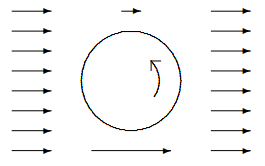

El campo circulante que ofrece el cilindro con su rotación ($Ω$) está dado por:

$$\begin{aligned}
  & v_r = 0
  \\
  & v_\phi = C/r, \quad C=\Omega a^2
  \\
  & v_z = 0
\end{aligned}$$

Donde $Ω$ corresponde a la velocidad angular del cilindro.

Como la ecuación de Laplace es lineal en P, podemos añadir el campo circulante a la solución del cilindro (1):

$$\begin{aligned}
  & v_r = \nabla_r \Psi = \frac{\partial \Psi}{\partial r} = U \cos \phi\left(1-\frac{a^2}{r^2}\right)
  \\
  & v_\phi = \nabla_\phi \Psi = \frac{1}{r} \frac{\partial \Psi}{\partial \phi} = -U \sin \phi\left(1+\frac{a^2}{r^2}\right) + \frac{C}{r}
  \\
  & v_z = 0
\end{aligned}$$


De acuerdo a las anteriores ecuaciones, la **presión** está dada por:

$$\Delta p=\rho_0 U \sin \phi\left(1+\frac{a^2}{r^2}\right) \frac{C}{r}$$

In [22]:
def vfield_magnus(x,y,z, t,vpars):
  U,a,omega = vpars
  C = omega*a**2

  # r = (x**2 + y**2 + z**2)**0.5
  r = (x**2 + y**2)**0.5
  phi = np.arctan2(y,x)

  # Coordenadas cilíndricas de la velocidad
  vr = U*np.cos(phi)*(1 - (a/r)**2)
  vphi = -U*np.sin(phi)*(1 + (a/r)**2) + C/r

  # Vectores unitarios cilíndricos
  er = np.array([np.cos(phi), np.sin(phi), 0])
  ephi = np.array([-np.sin(phi), np.cos(phi), 0])

  # Campo de velocidades en coords. cartesianas
  v = vr*er + vphi*ephi

  return v

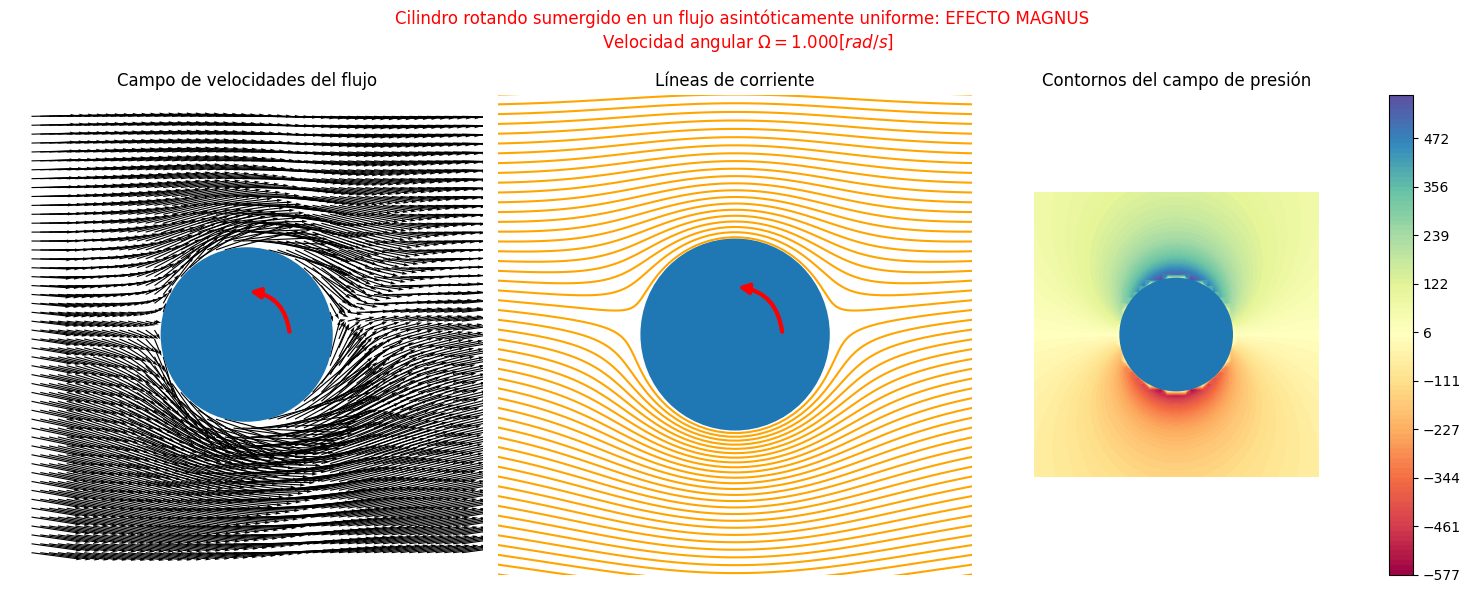

In [23]:
U, a = 1, 0.3   # Velocidad de escala, radio
omega = 1      # [rad/s] - Velocidad angular
vpars = U, a, omega
C = omega*a**2

rho0 = 1000    # [kg/m^3] - Densidad del flujo
t0 = 1      # Instante inicial

# ========================== Gráficos ==========================
NG = 50     # Tamaño de la malla
xs = np.linspace(-2.5*a, 2.5*a, NG)
ys = np.linspace(-2.5*a, 2.5*a, NG)
zs = np.zeros(NG)

XS,YS = np.meshgrid(xs,ys)
ZS = np.zeros_like(XS)

t = 0
VXS = np.zeros_like(XS)
VYS = np.zeros_like(XS)
VZS = np.zeros_like(XS)

for i in range(NG):
  for j in range(NG):
    if np.sqrt(XS[i,j]**2 + YS[i,j]**2) >= a:
      VXS[i,j], VYS[i,j], VZS[i,j] = vfield_magnus(XS[i,j],YS[i,j],ZS[i,j], t,vpars)

fig = plt.figure(figsize=(15,6))
fig.suptitle('Cilindro rotando sumergido en un flujo asintóticamente uniforme: EFECTO MAGNUS \n Velocidad angular $\Omega = %.3lf [rad/s]$' %omega, color='r')

# ======================== Campo de velocidad ========================
#
plt.subplot(131)
plt.title('Campo de velocidades del flujo')
plt.quiver(XS,YS, VXS,VYS, scale=10)
plt.gca().add_patch(Circle((0,0),a,fill='blue'))
plt.axis("off")
flecha = FancyArrowPatch([0.5*a,0], [0, 0.5*a], connectionstyle="arc3,rad=0.4", arrowstyle="-|>", mutation_scale=15, color='r', linewidth=3)
plt.gca().add_patch(flecha)

# ======================== Líneas de corriente ========================
#
plt.subplot(132)
plt.title('Líneas de corriente')

ts = np.linspace(0,30,2000)
x = XS[0,0]

# Integramos las velocidades que adquieran partículas iniciando desde la izquierda
for y in YS[:,0]:
  # Por la invariabilidad en z, sólo integramos en xy
  Y0 = [x,y,0]
  sols = odeint(streamline,Y0,ts, args=(t0,vfield_magnus,vpars))
  vxt, vyt = sols[:,0], sols[:,1]
  plt.plot(vxt, vyt, c='orange')

plt.gca().add_patch(Circle((0,0),a, fill='blue'))
plt.xlim(-2.5*a, 2.5*a)
plt.ylim(-2.5*a, 2.5*a)
plt.axis("off")
flecha = FancyArrowPatch([0.5*a,0], [0, 0.5*a], connectionstyle="arc3,rad=0.4", arrowstyle="-|>", mutation_scale=15, color='r', linewidth=3)
plt.gca().add_patch(flecha)

# ======================== Campo de presión ========================
#
RS = (XS**2 + YS**2)**0.5
PHIS = np.arctan2(YS,XS)

PS = rho0*U*np.sin(PHIS)*(1 + (a/RS)**2)*C/RS
PS[RS < a] = 0    # Condición de frontera

plt.subplot(133)
plt.title('Contornos del campo de presión')
c = plt.contourf(XS,YS, PS, levels=np.linspace(PS.min(),PS.max(),100), cmap="Spectral")
plt.colorbar(c)
plt.gca().add_patch(Circle((0,0), a, fill='blue',zorder=100))
plt.axis("equal")
plt.axis("off")
flecha = FancyArrowPatch([0.5*a,0], [0, 0.5*a], connectionstyle="arc3,rad=0.4", arrowstyle="-|>", mutation_scale=15, color='r', linewidth=3)
plt.gca().add_patch(flecha)

fig.tight_layout()

**Observaciones:**

* En este caso vemos que el campo de presión es mayor en la región superior del cilindro y menor en la región inferior, lo que se traduce en que en la región superior el fluido tenga menor velocidad que en la región inferior.

  Esto es gracias al arrastre que aplica el cilindro con su rotación a las capas de flujo. En la región superior la rotación va en sentido contrario al flujo, disminuyendo por tanto la velocidad de estas capas, caso contrario con la región inferior donde el momento del flujo es aumentado por la rotación del cilindro.

  Cuando el flujo choca con el cilindro, este comienza a halarlo y llevarlo con su rotación, y este efecto se propaga entre las capas del flujo hacia abajo creando así vorticidad, es por eso que en esta región se ve mayor amplitud de movimiento de las capas que en la región superior.

* Este fenómeno crea sustentación del cilindro. En términos coloquiales, e como si el cilindro se agarrara de las capas de fluido en dirección contraria al flujo, emprendiendo uuna trayectoria curva hacia arriba y hacia la izquierda. Caso contrario sería si el cilindro rotará en sentido horaria.

### 2) Flujo Laminar cilíndrico



Cuando el flujo laminar se produce dentro de una cilindro recto puede considerarse como el movimiento relativo de cilindros concéntricos de fluido, el cilindro exterior fijado en la pared de la tubería y los demás cilindros moviéndose a velocidades crecientes a medida que se acercan al centro de la tubería.

Los cilindros coaxiales infinitamente extendidos son simétricos en traslación a lo largo del eje de rotación y simétricos en rotación alrededor del mismo, por tanto, en coordenadas cilíndricas, un flujo circulante de simetría máxima adopta la forma:

$$\vec{v} = v_\phi(r) \hat{e}_\phi$$

La ecuación anterior permite inferir que en un flujo laminar a través de cilindros coaxiales, alguno en rotación, las capas circulares en su interior experimentan sólo una velocidad tangencial (de rotación) que es diferente para cada capa radial.

\
Este problema se describe a continuación con **la solución de Couette**, el cual consiste en un fluido contenido entre dos largos cilindros coaxiales de material con radios $a$ y $b>a$, donde el cilindro exterior se mantiene fijo y el interior rota con velocidad angular constante $\Omega$.

En coordenadas cilíndricas, para este caso, las condiciones de frontera están dadas por:

$$v_ϕ(a) = a Ω \quad y \quad v_ϕ(b) = 0$$

Y el ***campo de velocidades***:

$$\begin{aligned}
& v_ϕ = \frac{Ωa^2}{r} \frac{b^2-r^2}{b^2-a^2} \\
& v_r = 0 \\
& v_z = 0 \\
\end{aligned}$$

De esto se puede observar que la velocidad decrece desde el máximo en $v_ϕ(a)$ hasta cero en el cilindro fijo.

Por otro lado, ***el campo de presión*** está dado por:

$$P = P_0 + \frac{1}{2} \rho_0 \left(\frac{Ω a^2}{b^2-a^2}\right)^2 \left(r^2 - \frac{b^4}{r^2} + ab^2 \log \frac{b}{r} \right)$$

Donde $P_0$ es su valor en el cilindro exterior.

En el ***campo de estrés***, la única componente que no desaparece es:

$$σ_{ϕr} = -\frac{2 η Ω}{r^2} \frac{a^2 b^2}{b^2 - a^2}$$

Este campo representa la fricción viscosa entre las capas de fluido circulante.

**Sistema de coordenadas:**

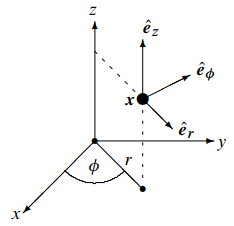

In [24]:
def vfield_laminar(x,y,z, t,vpars):
  omega, a, b = vpars

  r = (x**2 + y**2)**0.5
  phi = np.arctan2(y,x)

  # Coordenadas cilíndricas de la velocidad
  # Condiciones de frontera
  if r==a:
    vphi = a*omega
  elif r==b:
    vphi = 0
  else:
    vphi = (omega*a**2/r)*(b**2-r**2)/(b**2-a**2)

  # Vectores unitarios cilíndricos
  ephi = np.array([-np.sin(phi), np.cos(phi), 0])

  # Campo de velocidades en coords. cartesianas
  v = vphi*ephi

  return v

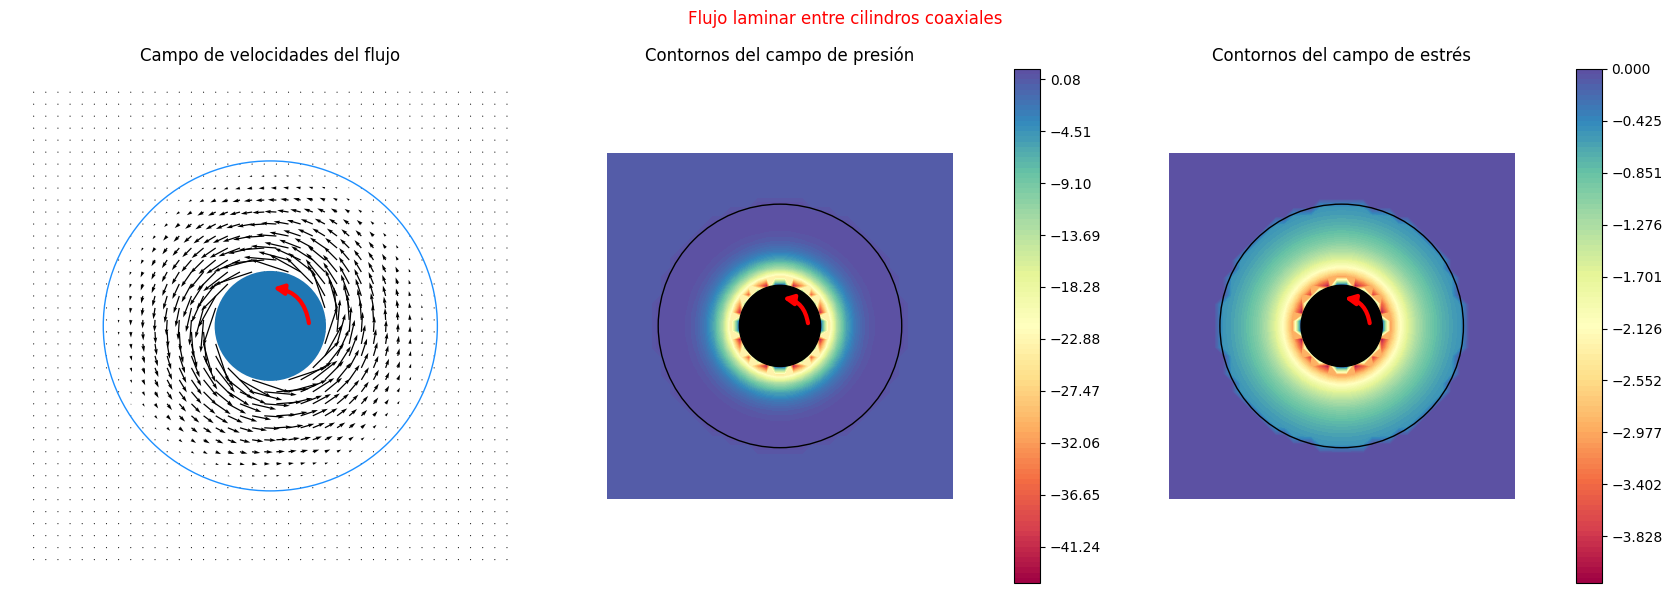

In [25]:
a, b = 0.2, 0.6   # Radio del cilindro interno y externo, respectivamente
omega = 2         # Velocidad angular
vpars = omega, a, b
rho0 = 1000    # [kg/m^3] - Densidad del flujo

NG = 40     # Tamaño de la malla
xs = np.linspace(-b-0.25, b+0.25, NG)
ys = np.linspace(-b-0.25, b+0.25, NG)
zs = np.zeros(NG)

XS,YS = np.meshgrid(xs,ys)
ZS = np.zeros_like(XS)
RS = (XS**2 + YS**2)**0.5

t = 0
VXS = np.zeros_like(XS)
VYS = np.zeros_like(XS)
VZS = np.zeros_like(XS)

for i in range(NG):     # Recorrido en y
  for j in range(NG):   # Recorrido en x
    if RS[i,j] >= a and RS[i,j] <= b:
      VXS[i,j], VYS[i,j], VZS[i,j] = vfield_laminar(XS[i,j],YS[i,j],ZS[i,j], t,vpars)

fig = plt.figure(figsize=(17,6))
fig.suptitle('Flujo laminar entre cilindros coaxiales', color='r')

# ======================== Campo de velocidad ========================
#
plt.subplot(131)
plt.title('Campo de velocidades del flujo')
plt.quiver(XS,YS, VXS,VYS, scale=5)
plt.gca().add_patch(Circle((0,0),a, fill='blue'))
plt.gca().add_patch(Circle((0,0),b, fill=False, color='dodgerblue'))
plt.axis("off")
flecha = FancyArrowPatch([0.7*a,0], [0, 0.7*a], connectionstyle="arc3,rad=0.4", arrowstyle="-|>", mutation_scale=15, color='r', linewidth=3)
plt.gca().add_patch(flecha)

# ======================== Campo de presión ========================
#
P0 = 1      # [Pa] - Presión en el cilindro exterior
PS = P0 + 0.5*rho0*(omega*a**2/(b**2-a**2))**2*(RS**2 - b**4/RS**2 + 4*b**2*np.log(b/RS))
PS[RS < a] = 0    # Condición de frontera
PS[RS > b] = 0

plt.subplot(132)
plt.title('Contornos del campo de presión')
c = plt.contourf(XS,YS, PS, levels=np.linspace(PS.min(),PS.max(),100), cmap="Spectral")
plt.colorbar(c)
plt.gca().add_patch(Circle((0,0),a, color='black'))
plt.gca().add_patch(Circle((0,0),b, fill=False, color='black'))
plt.axis("equal")
plt.axis("off")
flecha = FancyArrowPatch([0.7*a,0], [0, 0.7*a], connectionstyle="arc3,rad=0.4", arrowstyle="-|>", mutation_scale=15, color='r', linewidth=3)
plt.gca().add_patch(flecha)

# ======================== Campo de estrés ========================
#
nu = 1      # Viscocidad
sigma = -2*nu*omega*a**2*b**2/(RS**2*(b**2 - a**2))
sigma[RS < a] = 0    # Condición de frontera
sigma[RS > b] = 0

plt.subplot(133)
plt.title('Contornos del campo de estrés')
c = plt.contourf(XS,YS, sigma, levels=np.linspace(sigma.min(),sigma.max(),100), cmap="Spectral")
plt.colorbar(c)
plt.gca().add_patch(Circle((0,0),a, color='black'))
plt.gca().add_patch(Circle((0,0),b, fill=False, color='black'))
plt.axis("equal")
plt.axis("off")
flecha = FancyArrowPatch([0.7*a,0], [0, 0.7*a], connectionstyle="arc3,rad=0.4", arrowstyle="-|>", mutation_scale=15, color='r', linewidth=3)
plt.gca().add_patch(flecha)

fig.tight_layout()

**Observaciones:**

* Del campo de velocidades podemos notar que el cilindro rotante transfiere momentum a las capas de fluido circundantes, y este efecto se propaga de manera decreciente hacia las demás capas hasta llegar a ser prácticamente nulo cerca a la superficie del cilindro mayor.

* Esto también se puede inferior por el teorema de Bernoulli en el gráfico del campo de presiones, en el cual, cerca al cilindro rotante la presión es muy grande, lo que implica mayor velocidad para el flujo; y a medida que nos alejamos y nos acercamos al cilindro externo, la presión va aumentando, lo que implica menor velocidad para el flujo.

* En el campo de estrés también lo ponemos notar. El estrés es menor en las capas más internas, lo que se traduce en que hay menor cizalladura que pueda contrarrestar el movimiento de las capas de flujo, pero esta cizalladura se va haciendo más grande en dirección radial hasta aproximadamente detener el flujo cerca al cilindro externo.

#### **Animación del movimiento de partículas**

In [26]:
fig = plt.figure(figsize=(7,7))
plt.title('Trayectoria de partículas - Flujo laminar cilíndrico coaxial')

# animación
camera = Camera(fig)

ts = np.linspace(0,15,100)
Xs = np.linspace(a+0.01,b-0.01,10)

sols_vs = {}
# Integramos las velocidades que adquieran partículas iniciando desde la izquierda
for x in Xs:
  Y0 = [x,0,0]
  sols = odeint(streamline, Y0, ts, args=(0, vfield_laminar, vpars))
  vxt, vyt = sols[:,0], sols[:,1]
  sols_vs[x] = sols
  # plt.plot(vxt, vyt, c='r')

# Recorremos el diccionario para animar cada componente
for i in range(len(ts)):
  for x in Xs:
    plt.plot(sols_vs[x][:i,0], sols_vs[x][:i,1], 'r-')

  plt.xlim(-b-0.1, b+0.1)
  plt.ylim(-b-0.1, b+0.1)
  plt.gca().add_patch(Circle((0,0),a, color='gray'))
  plt.gca().add_patch(Circle((0,0),b, fill=False, color='black'))
  flecha = FancyArrowPatch([0.7*a,0], [0, 0.7*a], connectionstyle="arc3,rad=0.4", arrowstyle="-|>", mutation_scale=15, color='black', linewidth=3)
  plt.gca().add_patch(flecha)
  plt.axis("equal")
  plt.axis("off")

  camera.snap()

plt.close()

animation = camera.animate()#blit=True, interval=30)
animation.save('laminal_coaxial.gif', writer='pillow')

In [27]:
HTML(animation.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

### 3) Flujo inducido por gravedad


La gravedad también puede inducir un movimiento y circulación de un fluido, cuando las fronteras por las que se mueve el flujo se inclinen con un ángulo.

#### **Placas paralelas inclinadas**

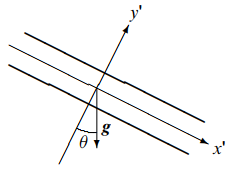

Elegimos un sistema de coordenadas rotado con el eje $x'$ en la dirección del flujo y eje $y'$ ortogonal a las placas. Suponiendo una gravedad constante, el campo gravitatorio también está inclinado un ángulo $θ$ respecto al eje $y'$ negativo.

Suponiendo que no hay diferencia de presión entre los extremos de las placas en $x=0$ y $x=L$ se deduce que $p_0(x)$ también debe ser constante: $p_0(x) = p_0$. Por la condición de no deslizamiento del fluido cerca a las placas, $v_x(y'=0) = v_x(y'=d) = 0$. Finalmente, el ***campo de velocidad*** está dado por:

$$v_x = \frac{g_0 \sin \theta}{2 \nu}\left(a^2-(y')^2\right)$$

Y el ***campo de presión***:

$$P=p_0-\rho_0 g_0 y' \cos \theta$$

Donde $P_0$ es la presión constante en el plano central $y'=0$

\
**Observación:** La presión es para todos simplemente la presión hidrostática en un campo de gravedad constante de fuerza $g_0 cos(θ)$.

In [28]:
def rotar_vector(vec, theta):
  Mrot = np.array([
      [np.cos(theta), -np.sin(theta), 0],
      [np.sin(theta), np.cos(theta), 0],
      [0, 0, 1]
  ])
  return np.dot(Mrot, vec)
# ==============================================================================

# Campo de velocidades - placas inclinadas
def vfield_grav(x,y,z,t,vps):
  #parámetros.
  a,theta,nu,g0,rho0,P0 = vps

  # coordenadas rotadas.
  xp,yp,zp = rotar_vector(np.array([x,y,z]), theta)

  # componentes no nulas de la velocidad en el sistema rotado.
  vxp = (g0*np.sin(theta)/(2*nu))*(a**2 - yp**2)
  P = P0 - rho0*g0*yp*np.cos(theta)

  # cambio de coordenadas de las componentes de la velocidad.
  vx, vy, vz = rotar_vector(np.array([vxp, 0, 0]), -theta)

  return np.array([vx,vy,vz,P])

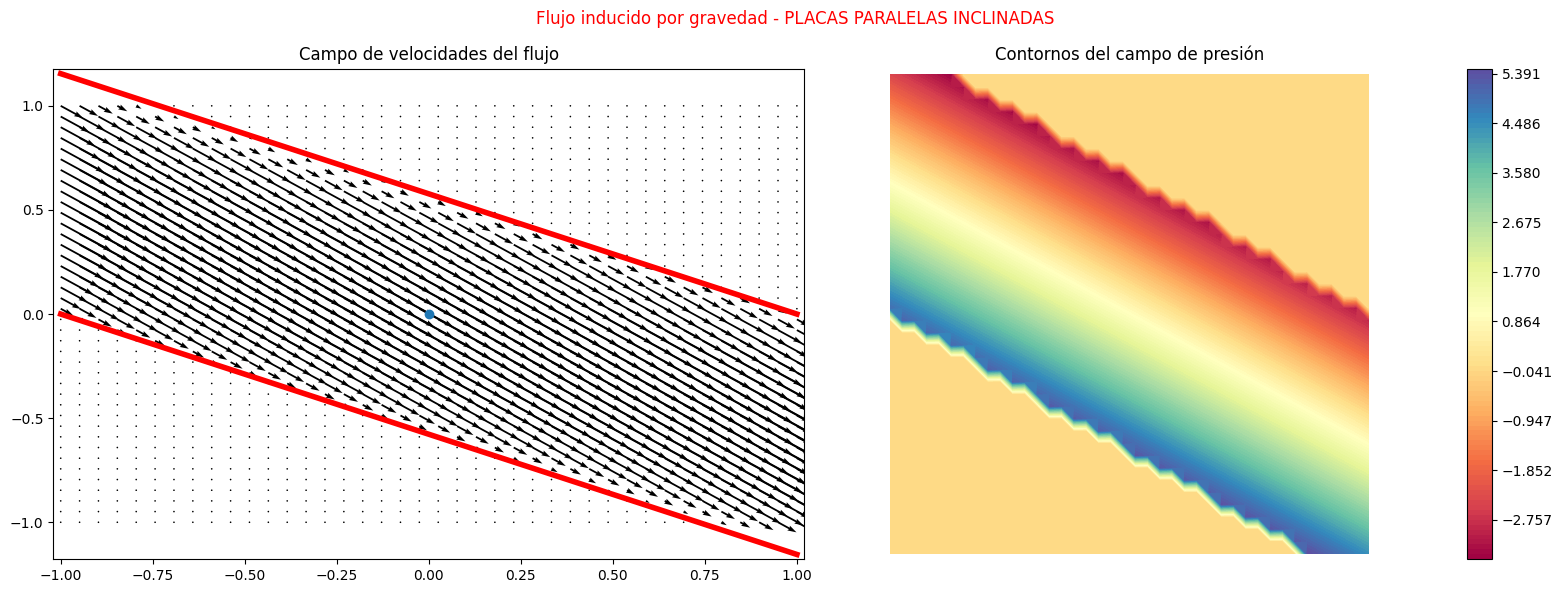

In [29]:
nu = 0.2      # [m^2/s]
g0 = 9.8      # [m/s^2] - Gravedad
theta = np.radians(30)
a = 0.5       # Tamaño del canal
rho0 = 1      # [kg/m^3]
P0 = 1        # [Pa] - Presión en la placa central
vpars = (theta, a, nu, g0, rho0, P0)

# Frontera inferior
ay = a/np.cos(theta)
ysup = lambda x: -np.tan(theta)*x + ay
yinf = lambda x: ysup(x) - 2*ay

NG = 40     # Tamaño de la malla
xs = np.linspace(-1,1,NG)
ys = np.linspace(-1,1,NG)
zs = np.zeros(NG)

XS,YS = np.meshgrid(xs,ys)
ZS = np.zeros_like(XS)

t = 0
VXS = np.zeros_like(XS)
VYS = np.zeros_like(XS)
VZS = np.zeros_like(XS)
PS = np.zeros_like(XS)

for i in range(NG):
    for j in range(NG):
        if YS[i,j] > yinf(XS[i,j]) and YS[i,j] < ysup(XS[i,j]):
          VXS[i,j],VYS[i,j],VZS[i,j],PS[i,j] = vfield_grav(XS[i,j],YS[i,j],ZS[i,j], t,vpars)

# ======================== Campo de velocidad ========================
#
fig = plt.figure(figsize=(16,6))
fig.suptitle('Flujo inducido por gravedad - PLACAS PARALELAS INCLINADAS', color='r')

plt.subplot(121)
plt.title('Campo de velocidades del flujo')
plt.quiver(XS,YS, VXS,VYS, scale=40)
plt.plot(xs, ysup(xs), c='r', linewidth=4)
plt.plot(xs, yinf(xs), c='r', linewidth=4)
plt.axis("on")
plt.margins(0.01, 0.01)
plt.plot(0,0, 'o')

# ======================== Campo de velocidad ========================
#
plt.subplot(122)
plt.title('Contornos del campo de presión')
c = plt.contourf(XS,YS, PS, levels=np.linspace(PS.min(),PS.max(),100), cmap="Spectral")
plt.colorbar(c)
plt.axis("equal")
plt.axis("off")

fig.tight_layout()

**Nota:** Fue necesario realizar el gráfico para el campo de velocidades más grande para observar bien el comportamiento de este.

**Observaciones:**

* Del campo de velocidad podemos notar que el flujo está ligeramente inclinado (no era posible verlo con un tamaño menor ni con flechas grandes), esto posiblemente se deba al efecto de la gravedad que consiste en "halar" las capas de flujo hacia la frontera inferior.

* También podemos observar que el campo de velocidad es mayor en las regiones centrales que en las regiones cercas a las superficies, adoptando así un comportamiento parabólico. Esto concuerda con el hecho de que la ecuación para el campo de velocidad $v_x(y')$ corresponde a una parábola.

* En el campo de presión observamos que la presión aumenta hacia la superficie inferior y disminuye en la superficie superior, por tanto, el gradiente de presión apunta hacia la superficie inferior.

  Por la cizalladura, en las superficies las capas de flujo disminuyen su velocidad, y esto se ve también en el campo de presión. En el límite superior el gradiente de presión es negativo, pero es magnitud es alto, lo que explica que las velocidades sean más grandes en capas centrales donde las presiones son cercanas a cero.

#### **Flujo inclinado con superficie abierta**

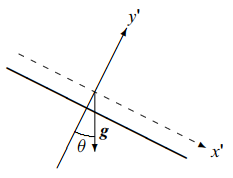

Otro ejemplo de flujo puramente gravitatorio es el caso de una capa líquida de espesor constante $a$ que fluye por una placa inclinada con una superficie abierta.

Sobre el plano inclinado, en $y'=-a$, la condición de no deslizamiento exige que $v_x(-a) = 0$, mientras que en la superficie abierta, en $y'=0$, la presión debe ser constante y el esfuerzo de corte desaparecer: $σ_{xy} = η \frac{dv_x}{dy} = 0$. Teniendo en cuenta esto, la velocidad y la presión vienen dadas por las mismas ecuaciones del caso de flujo entre placas paralelas inclinadas.

De acuerdo a lo anterior, el perfil de velocidad tiene ahora su máximo en la superficie abierta.

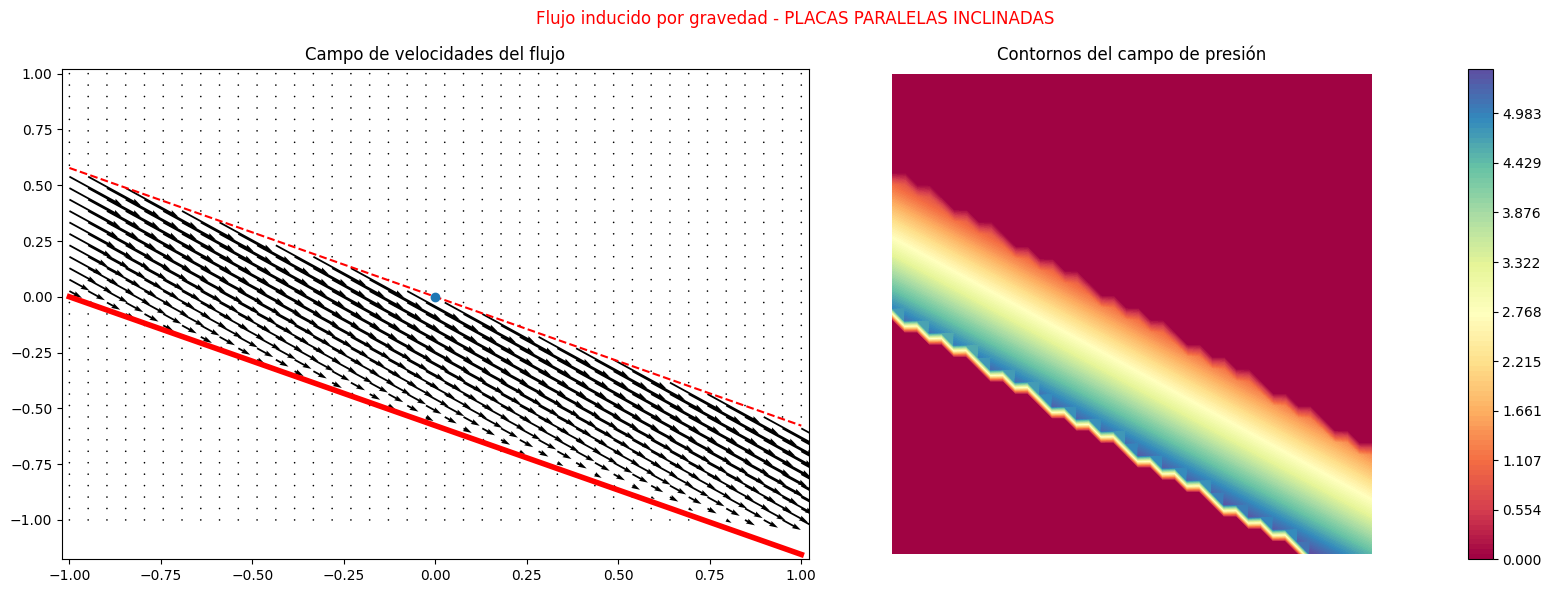

In [30]:
nu = 0.2        # [m^2/s]
g0 = 9.8      # [m/s^2] - Gravedad
theta = np.radians(30)
a = 0.5       # Tamaño del canal
rho0 = 1      # [kg/m^3]
P0 = 1       # [Pa] - Presión en la placa central
vpars = (theta, a, nu, g0, rho0, P0)

# Fronteras del canal
ay = a/np.cos(theta)
ysup = lambda x: -np.tan(theta)*x       # Superficie abierta
yinf = lambda x: -np.tan(theta)*x - ay

NG = 40     # Tamaño de la malla
xs = np.linspace(-1,1,NG)
ys = np.linspace(-1,1,NG)
zs = np.zeros(NG)

XS,YS = np.meshgrid(xs,ys)
ZS = np.zeros_like(XS)

t = 0
VXS = np.zeros_like(XS)
VYS = np.zeros_like(XS)
VZS = np.zeros_like(XS)
PS = np.zeros_like(XS)

for i in range(NG):
    for j in range(NG):
        if YS[i,j] > yinf(XS[i,j]) and YS[i,j] < ysup(XS[i,j]):
          VXS[i,j],VYS[i,j],VZS[i,j],PS[i,j] = vfield_grav(XS[i,j],YS[i,j],ZS[i,j], t,vpars)

# ======================== Campo de velocidad ========================
#
fig = plt.figure(figsize=(16,6))
fig.suptitle('Flujo inducido por gravedad - PLACAS PARALELAS INCLINADAS', color='r')

plt.subplot(121)
plt.title('Campo de velocidades del flujo')
plt.quiver(XS,YS, VXS,VYS, scale=40)
plt.plot(xs, ysup(xs), 'r--')
plt.plot(xs, yinf(xs), c='r', linewidth=4)
plt.plot(0,0,'o')
plt.axis("on")
plt.margins(0.01, 0.01)

# ======================== Campo de velocidad ========================
#
plt.subplot(122)
plt.title('Contornos del campo de presión')
c = plt.contourf(XS,YS, PS, levels=np.linspace(PS.min(),PS.max(),100), cmap="Spectral")
plt.colorbar(c)
plt.axis("equal")
plt.axis("off")

fig.tight_layout()

**Observaciones:**

* En este caso podemos observar un comportamiento ligeralmente distinto al caso anterior. La diferencia es que, como no hay capa superior sólida (capa abierta), no existe cizalladura y por tanto el flujo alcanza una máxima velocidad allí.

  Esto también se puede ver reflejado en el campo de presiones, el cual la presión disminuye del máximo en la superficie inferior y alcanza aproximadamente una presión nula en la superficie abierta.

### 4) Flujo laminar en tuberías

Resolver las ecuaciones de Navier-Stokes en el caso de el problema de *flujo laminar en tubería* (página 268, Lautrup, 2011). Hacer diagrama del campo de velocidades y calcular numéricamente el valor de cantidades como Q y U.


En esta sección abordamos el problema de fluidos transportados por la presión a través de tuberías de sección circular, a partir de la ***solución de Poiseuille***:

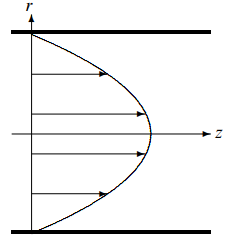

En un tubo cilíndrico circular de longitud infinita ocurre invarianza ante traslaciones a lo largo de su eje y rotaciones alrededor del mismo. Considerando una tubería de radio interior $a$ y diámetro $d=2a$, por la condición de no deslizamiento se tiene que $v_z(a) = 0$ y por tanto el **campo de velocidades** está dado por:

$$v_z = \frac{G}{4 \eta} (a^2 - r^2)$$

Donde $r$ es la distancia radial al eje del cilindro y $G$ corresponde al gradiente de presión. En el caso de un tubería finita de tamaño L:

$$G = \frac{\Delta P}{L} = \frac{P(x=0) - P(x=L)}{L}$$

De acuerdo a este, el máximo valor de velocidad es alcanzado en el centro del tubo, con una valor de: $v_z^{máx} = GA^2/4η$.


La **tasa de descarga volumétrica** se puede calcular como:

$$Q = \frac{\pi a^4}{8 η} G$$

Esta ecuación permiten inferir que fluye mucha más agua a través de una tubería más ancha para una presión de impulsión dada, y esto se explica porque el esfuerzo de cizallamiento de las paredes es menos capaz de retener el fluido.

La **velocidad media del flujo** en la sección transversal de la tubería puede calcularse a partir del caudal. Esto es:

$$U = \frac{G a^2}{8 η}$$

In [31]:
def vfield_tuberia(r, vpars):
  G, a, eta = vpars

  vz = G/(4*eta)*(a**2 - r**2)

  # Vector unitario en z
  ez = np.array([1,0])

  # Campo de velocidades en coords. cartesianas
  v = vz*ez

  return v

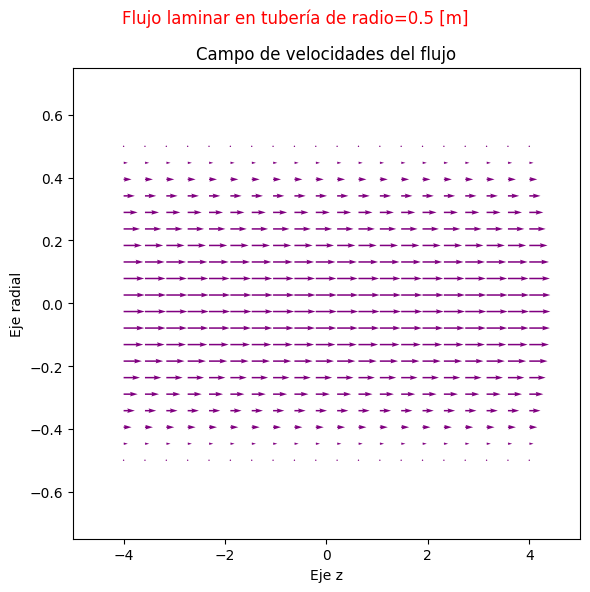

In [32]:
G = 2    # [Pa] - Gradiente de presión
a = 0.5      # Radio de la tubería
eta = 0.5    # [Pa s] - Viscocidad

vpars = (G, a, eta)

# Fronteras del canal
# ay = a/np.cos(theta)
# ysup = lambda x: -np.tan(theta)*x       # Superficie abierta
# yinf = lambda x: -np.tan(theta)*x - ay

NG = 20     # Tamaño de la malla
zs = np.linspace(-4,4,NG)
rs = np.linspace(-a,a,NG)

ZS,RS = np.meshgrid(zs,rs)

VRS = np.zeros_like(ZS)
VZS = np.zeros_like(ZS)

for i in range(NG):
  for j in range(NG):
    VZS[i,j],VRS[i,j] = vfield_tuberia(RS[i,j], vpars)

# ======================== Campo de velocidad ========================
#
fig = plt.figure(figsize=(6,6))
fig.suptitle('Flujo laminar en tubería de radio=%.1lf [m]' %a, color='r')

plt.title('Campo de velocidades del flujo')
plt.quiver(ZS,RS, VZS,VRS, scale=6, color='purple')
plt.ylim(min(rs)-0.25, max(rs)+0.25)
plt.xlim(min(zs)-1, max(zs)+1)
plt.axis("on")
plt.xlabel('Eje z')
plt.ylabel('Eje radial')

fig.tight_layout()

**Observación:** Podemos notar del gráfico que el campo de velocidad es máximo en el centro de la tubería, y decrece hacia los extremos, lo cual es un comportamiento esperado gracias a la condición de no deslizamiento en las paredes.

In [33]:
Q = np.pi*a**4*G/(8*eta)
U = G*a**2/(8*eta)

print('Tasa de descarga volumétrica: \t Q = %.3lf [m^3/s]' %Q)
print('Velocidad media del flujo:    \t U = %.3lf [m/s]' %U)

Tasa de descarga volumétrica: 	 Q = 0.098 [m^3/s]
Velocidad media del flujo:    	 U = 0.125 [m/s]
